# Task 3 — Nested Cross-Validation: Baseline & rnCV
MLCB 2026 | Assignment #2

In [1]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('../src'))

from nested_cv import RepeatedNestedCV
from functions import load_data

## 3.0  Load Data

In [2]:
data = load_data('../data/students_dataset.csv')

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
X = data.drop(columns=['num'])
y = data['num']

print(f'X shape: {X.shape}  |  Class balance: {y.value_counts().to_dict()}')

X shape: (242, 13)  |  Class balance: {0: 131, 1: 111}


## 3.1  Define Estimators

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

SEED = 42

estimators = {
    'LR': LogisticRegression(penalty='elasticnet', solver='saga', max_iter=5000, random_state=SEED, l1_ratio=0.5),
    'GNB': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis(),
    'RF': RandomForestClassifier(random_state=SEED, n_estimators=300),
    'LightGBM': LGBMClassifier(random_state=SEED, n_estimators=300, verbose=-1),
    'XGBoost':  XGBClassifier(random_state=SEED, n_estimators=300, eval_metric='logloss', verbosity=0),
    'CatBoost': CatBoostClassifier(random_state=SEED, verbose=False),
}

## 3.2  Define Hyperparameter Spaces (Optuna)

In [ ]:
# Each function receives an Optuna trial and returns a param dict.
# Only params relevant to each model are included to keep the search tractable.

def lr_space(trial):
    return {
        'C': trial.suggest_float('C', 1e-3, 10, log=True),
        'l1_ratio': trial.suggest_float('l1_ratio', 0.0, 1.0),
    }

def gnb_space(trial):
    return {
        'var_smoothing': trial.suggest_float('var_smoothing', 1e-10, 1e-1, log=True),
    }

def lda_space(trial):
    return {'solver': 'lsqr'}

def rf_space(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight': 'balanced',
    }

def lgbm_space(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 16, 64),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'class_weight': 'balanced',
    }

def xgb_space(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': (y == 0).sum() / (y == 1).sum(),  # handles imbalance
    }

def catboost_space(trial):
    return {
        'iterations': trial.suggest_int('iterations', 100, 500, step=100),
        'depth': trial.suggest_int('depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10, log=True),
        'auto_class_weights': 'Balanced',
    }

param_spaces = {
    'LR': lr_space,
    'GNB': gnb_space,
    'LDA': lda_space,
    'RF': rf_space,
    'LightGBM': lgbm_space,
    'XGBoost': xgb_space,
    'CatBoost': catboost_space,
}

print('Estimators and search spaces defined.')

Estimators and search spaces defined.


## 3.3  Baseline: R=10 × 5-Fold CV (No Tuning)
Inner loop disabled (`tune=False`). Default hyperparameters only.

In [6]:
baseline_rncv = RepeatedNestedCV(
    estimators=estimators,
    param_spaces=param_spaces,
    categorical_cols=categorical_features,
    numerical_cols=numerical_features,
    R=10, N=5, K=3,
    n_trials=50,
    inner_metric='AUC',
    base_seed=42,
)

print('Running baseline (no tuning) — R=10, N=5 ...')
baseline_rncv.fit(X, y, tune=False)
print('Done.')

baseline_summary = baseline_rncv.summary()

# Show key metrics only
key_cols = [c for c in baseline_summary.columns if c.endswith('_median')]
print('\nBaseline Median Metrics (default hyperparameters):')
display(baseline_summary[key_cols].round(4))

Running baseline (no tuning) — R=10, N=5 ...
Done.

Baseline Median Metrics (default hyperparameters):


,MCC_median,AUC_median,BA_median,F1_median,Recall_median,Specificity_median,Precision_median,PRAUC_median
Estimator,,,,,,,,
LR,0.6643,0.9015,0.8280,0.8090,0.8182,0.8846,0.8333,0.8986
GNB,0.5314,0.8833,0.7616,0.7524,0.8636,0.6603,0.6897,0.8575
LDA,0.6302,0.8902,0.8094,0.7907,0.7727,0.8846,0.8333,0.8928
RF,0.5882,0.8880,0.7885,0.7727,0.7727,0.8462,0.7958,0.8924
LightGBM,0.5446,0.8525,0.7722,0.7500,0.7332,0.8077,0.7550,0.8452
XGBoost,0.5854,0.8741,0.7920,0.7780,0.7727,0.8148,0.7860,0.8737
CatBoost,0.5878,0.8794,0.7920,0.7710,0.7727,0.8462,0.8000,0.8811


## 3.4  Full rnCV: R=10, N=5 Outer, K=3 Inner (With Tuning)
Optuna runs up to 50 trials per inner fold. This takes a few minutes.

In [5]:
rncv = RepeatedNestedCV(
    estimators=estimators,
    param_spaces=param_spaces,
    categorical_cols=categorical_features,
    numerical_cols=numerical_features,
    R=10, N=5, K=3,
    n_trials=50,
    inner_metric='AUC',
    base_seed=42,
)

print('Running full rnCV (with tuning) — R=10, N=5, K=3 ...')
rncv.fit(X, y, tune=True)
print('Done.')

results = rncv.summary()

key_cols = [c for c in results.columns if c.endswith('_median')]
print('\nrnCV Median Metrics:')
display(results[key_cols].round(4))

Running full rnCV (with tuning) — R=10, N=5, K=3 ...
Done.

rnCV Median Metrics:


,MCC_median,AUC_median,BA_median,F1_median,Recall_median,Specificity_median,Precision_median,PRAUC_median
Estimator,,,,,,,,
LR,0.6497,0.8990,0.8180,0.7958,0.7777,0.8846,0.8461,0.9016
GNB,0.6497,0.9007,0.8191,0.8000,0.7727,0.8846,0.8417,0.8965
LDA,0.6302,0.8902,0.8094,0.7907,0.7727,0.8846,0.8333,0.8928
RF,0.5859,0.8825,0.7860,0.7755,0.7391,0.8462,0.8000,0.8938
LightGBM,0.5854,0.8756,0.7920,0.7710,0.7559,0.8305,0.8000,0.8843
XGBoost,0.6238,0.8813,0.8007,0.7710,0.7332,0.8519,0.8333,0.8838
CatBoost,0.6136,0.8829,0.7988,0.7815,0.7727,0.8682,0.8248,0.8891


## 3.5  Results Visualisation

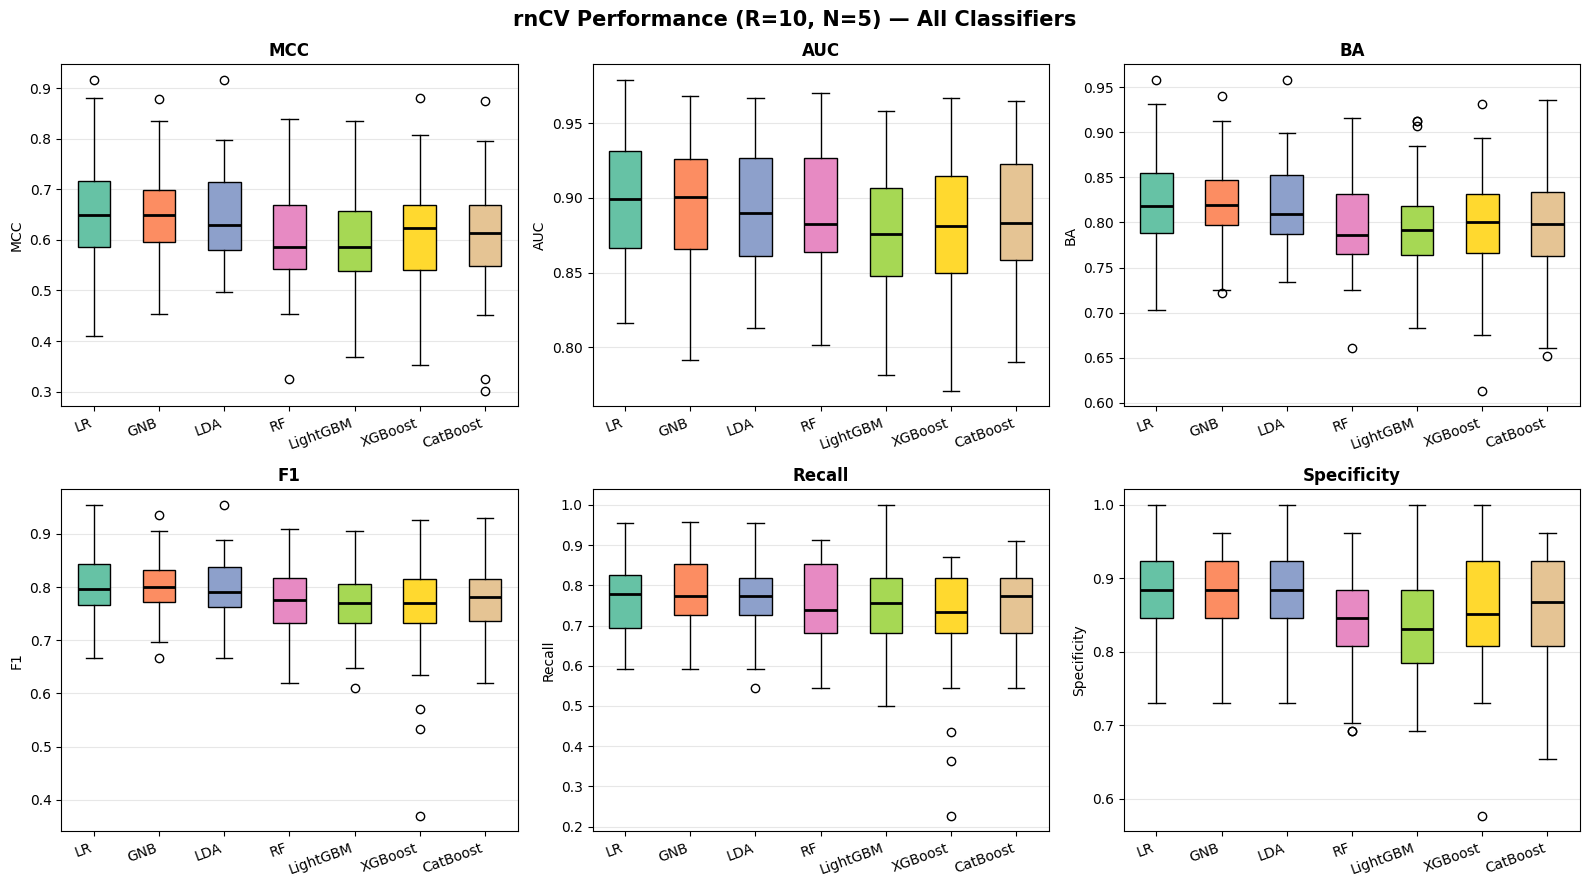

In [ ]:
#Per-metric box plots (rnCV raw scores)
metrics_to_plot = ['MCC', 'AUC', 'BA', 'F1', 'Recall', 'Specificity']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
palette = sns.color_palette('Set2', n_colors=len(estimators))

for ax, metric in zip(axes, metrics_to_plot):
    data_list = [rncv.get_scores(name)[metric].values for name in estimators]
    bp = ax.boxplot(data_list, patch_artist=True, medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
    ax.set_xticks(range(1, len(estimators)+1))
    ax.set_xticklabels(list(estimators.keys()), rotation=20, ha='right')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('rnCV Performance (R=10, N=5) — All Classifiers', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig_rncv_boxplots.png', bbox_inches='tight', dpi=130)
plt.show()

In [ ]:
# MCC + AUC median comparison table with 95% CI
ci_cols = []
for m in ['MCC', 'AUC', 'BA', 'F1']:
    ci_cols += [f'{m}_median', f'{m}_CI_lo', f'{m}_CI_hi']

print('Median metrics with 95% bootstrap CI (rnCV):')
display(results[ci_cols].round(4))

Median metrics with 95% bootstrap CI (rnCV):


,MCC_median,MCC_CI_lo,MCC_CI_hi,AUC_median,AUC_CI_lo,AUC_CI_hi,BA_median,BA_CI_lo,BA_CI_hi,F1_median,F1_CI_lo,F1_CI_hi
Estimator,,,,,,,,,,,,
LR,0.6497,0.6225,0.6764,0.8990,0.8779,0.9161,0.8180,0.8049,0.8322,0.7958,0.7815,0.8182
GNB,0.6497,0.6272,0.6694,0.9007,0.8824,0.9126,0.8191,0.8059,0.8308,0.8000,0.7907,0.8095
LDA,0.6302,0.6080,0.6763,0.8902,0.8744,0.9041,0.8094,0.8002,0.8336,0.7907,0.7727,0.8182
RF,0.5859,0.5535,0.6333,0.8825,0.8753,0.9108,0.7860,0.7734,0.8162,0.7755,0.7500,0.8000
LightGBM,0.5854,0.5505,0.6234,0.8756,0.8589,0.8951,0.7920,0.7722,0.8059,0.7710,0.7500,0.7827
XGBoost,0.6238,0.5832,0.6405,0.8813,0.8636,0.8973,0.8007,0.7839,0.8194,0.7710,0.7562,0.8000
CatBoost,0.6136,0.5795,0.6643,0.8829,0.8658,0.8936,0.7988,0.7811,0.8252,0.7815,0.7578,0.8000


## 3.6  Winner Selection

**Criteria (in order):**
1. Highest **median MCC** across 50 outer folds (R×N = 10×5). MCC is the primary metric because it accounts for both classes and is robust to class imbalance.
2. High median **AUC** and **Balanced Accuracy** as supporting metrics.
3. If two models are within each other's **95% CI on MCC**, compare on AUC and F1.

Clinically, false negatives (missed disease) are more costly than false positives, so we also check **Recall (Sensitivity)** as a secondary tie-breaker.

In [ ]:
# Rank by MCC median
ranking = results['MCC_median'].sort_values(ascending=False)
print('Estimators ranked by median MCC (rnCV):')
for rank, (name, mcc) in enumerate(ranking.items(), 1):
    lo = results.loc[name, 'MCC_CI_lo']
    hi = results.loc[name, 'MCC_CI_hi']
    auc = results.loc[name, 'AUC_median']
    ba  = results.loc[name, 'BA_median']
    print(f'{rank}. {name:<12} MCC={mcc:.4f} [{lo:.4f}, {hi:.4f}]  '
          f'AUC={auc:.4f}  BA={ba:.4f}')

winner = ranking.index[0]
print(f'\n>>> Winner: {winner}')

Estimators ranked by median MCC (rnCV):
  1. LR           MCC=0.6497 [0.6225, 0.6764]  AUC=0.8990  BA=0.8180
  2. GNB          MCC=0.6497 [0.6272, 0.6694]  AUC=0.9007  BA=0.8191
  3. LDA          MCC=0.6302 [0.6080, 0.6763]  AUC=0.8902  BA=0.8094
  4. XGBoost      MCC=0.6238 [0.5832, 0.6405]  AUC=0.8813  BA=0.8007
  5. CatBoost     MCC=0.6136 [0.5795, 0.6643]  AUC=0.8829  BA=0.7988
  6. RF           MCC=0.5859 [0.5535, 0.6333]  AUC=0.8825  BA=0.7860
  7. LightGBM     MCC=0.5854 [0.5505, 0.6234]  AUC=0.8756  BA=0.7920

>>> Winner: LR
